In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [16]:
df.shape

(406829, 9)

In [17]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

# Revenu total

In [20]:
df["Revenue"].sum()

np.float64(8300065.813999999)

# Revenue par pays 

In [21]:
df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

# Les clients VIP

In [24]:
df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

# Les produits les plus vendus

In [27]:
df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(50)

Description
REGENCY CAKESTAND 3 TIER               132870.40
WHITE HANGING HEART T-LIGHT HOLDER      93823.85
JUMBO BAG RED RETROSPOT                 83236.76
PARTY BUNTING                           67687.53
POSTAGE                                 66710.24
ASSORTED COLOUR BIRD ORNAMENT           56499.22
RABBIT NIGHT LIGHT                      51137.80
CHILLI LIGHTS                           45936.81
PAPER CHAIN KIT 50'S CHRISTMAS          41500.48
PICNIC BASKET WICKER 60 PIECES          39619.50
BLACK RECORD COVER FRAME                39009.38
JUMBO BAG PINK POLKADOT                 36473.01
SPOTTY BUNTING                          35056.44
DOORMAT KEEP CALM AND COME IN           34312.60
WOOD BLACK BOARD ANT WHITE FINISH       34307.06
SET OF 3 CAKE TINS PANTRY DESIGN        32607.80
JAM MAKING SET WITH JARS                31658.47
JUMBO BAG STRAWBERRY                    30195.71
HEART OF WICKER LARGE                   28331.45
VICTORIAN GLASS HANGING T-LIGHT         28152.86
HEART OF

# Revenue par mois

In [28]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Revenue"].sum()
monthly_sales

Month
2010-12     554604.020
2011-01     475074.380
2011-02     436546.150
2011-03     579964.610
2011-04     426047.851
2011-05     648251.080
2011-06     608013.160
2011-07     574238.481
2011-08     616368.000
2011-09     931440.372
2011-10     974603.590
2011-11    1132407.740
2011-12     342506.380
Freq: M, Name: Revenue, dtype: float64

# Saisonalité des ventes

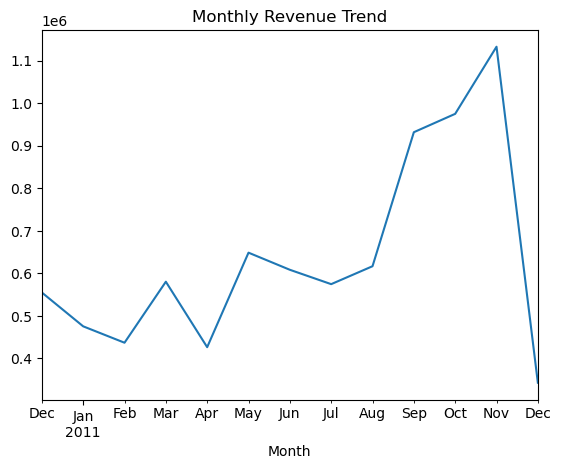

In [29]:
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.show()

# Nombre de commandes par clients

In [30]:
df.groupby("CustomerID")["InvoiceNo"].nunique().describe()

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64

# Repartition par region

In [31]:
df["Country"].value_counts().head(10)

Country
United Kingdom    361878
Germany             9495
France              8491
EIRE                7485
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1480
Australia           1259
Name: count, dtype: int64

# Valeur moyenne par commande

In [32]:
df["Revenue"].sum() / df["InvoiceNo"].nunique()

np.float64(374.0453273546642)